In [3]:
pip install pandas matplotlib seaborn scikit-learn

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/students.csv')

In [ ]:
# --------------------------------------
# Task 1 - Data Exploration with Pandas
# --------------------------------------


# load csv
df = pd.read_csv("students.csv")

# first 5 rows
print("First 5 rows:")
print(df.head())

# shape and datatypes
print("\nShape:", df.shape)
print("\nData Types:")
print(df.dtypes)

# summary stats
print("\nSummary Statistics:")
print(df.describe())

# pass fail count
print("\nPass / Fail Count:")
print(df["passed"].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

# averages for pass students
pass_avg = df[df["passed"] == 1][subject_cols].mean()
fail_avg = df[df["passed"] == 0][subject_cols].mean()

print("\nAverage score for Pass students:")
print(pass_avg)

print("\nAverage score for Fail students:")
print(fail_avg)

# overall average per student
df["overall_avg"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["overall_avg"].idxmax()]

print("\nTop Student:")
print(top_student["name"], "-", top_student["overall_avg"])

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    science    english    

In [10]:
# ---------------------------------------------
# Task 2 -  Data Visualization with Matplotlib
# ---------------------------------------------

df["avg_score"] = df[subject_cols].mean(axis=1)

Plot 1 — Bar chart

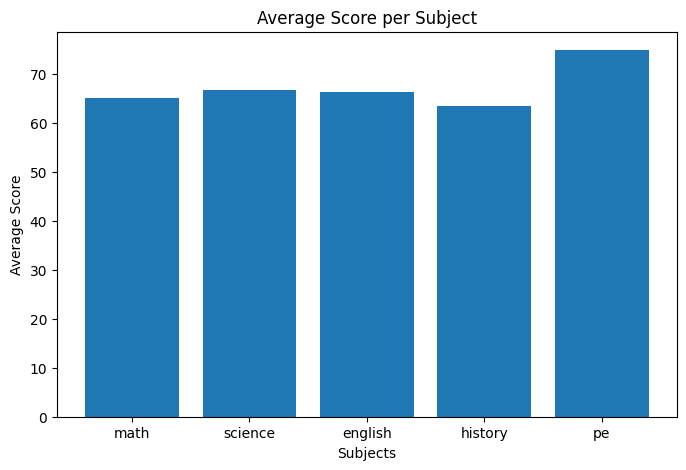

In [11]:
subject_means = df[subject_cols].mean()

plt.figure(figsize=(8,5))
plt.bar(subject_means.index, subject_means.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

Plot 2 — Histogram

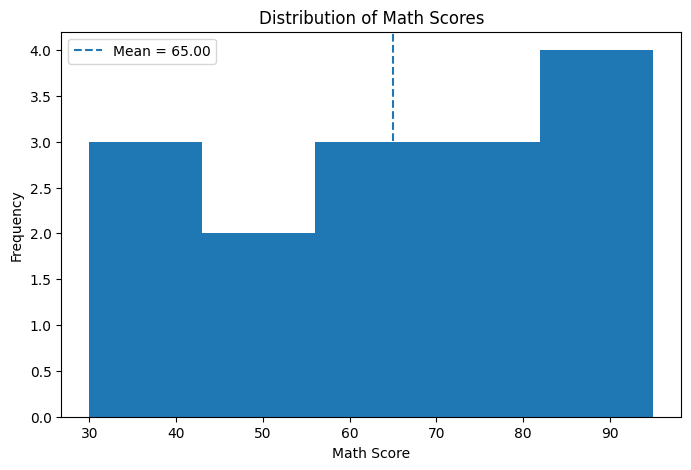

In [12]:
mean_math = df["math"].mean()

plt.figure(figsize=(8,5))
plt.hist(df["math"], bins=5)
plt.axvline(mean_math, linestyle="--", label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

Plot 3 — Scatter Plot

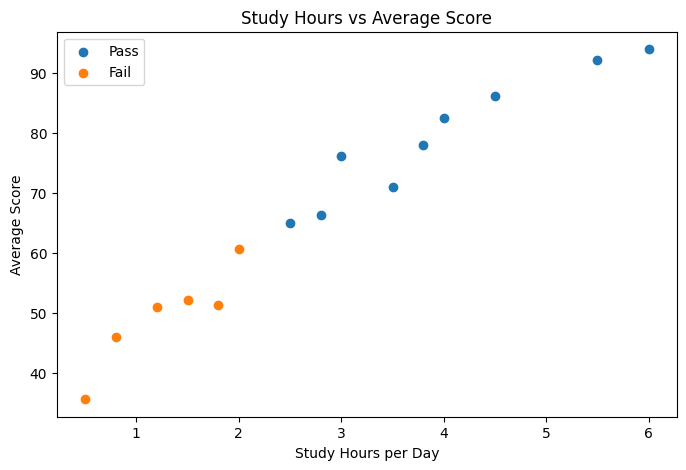

In [13]:
pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

plt.figure(figsize=(8,5))

plt.scatter(
    pass_students["study_hours_per_day"],
    pass_students["avg_score"],
    label="Pass"
)

plt.scatter(
    fail_students["study_hours_per_day"],
    fail_students["avg_score"],
    label="Fail"
)

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

Plot 4 — Box plot

/tmp/ipykernel_5255/1175932533.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


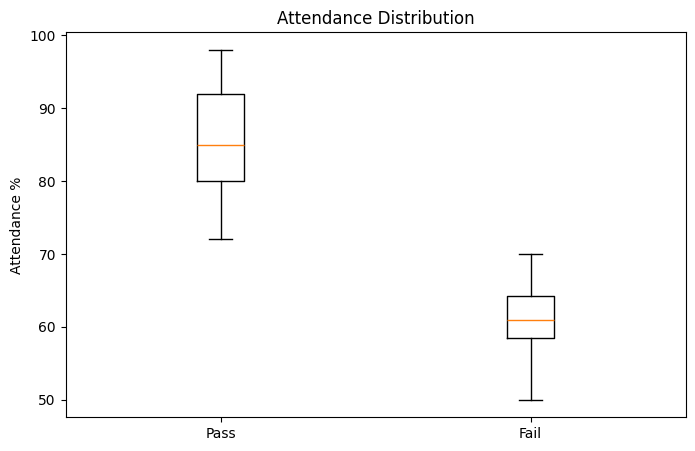

In [14]:
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

plt.figure(figsize=(8,5))
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
plt.title("Attendance Distribution")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

Plot 5 — Line plot

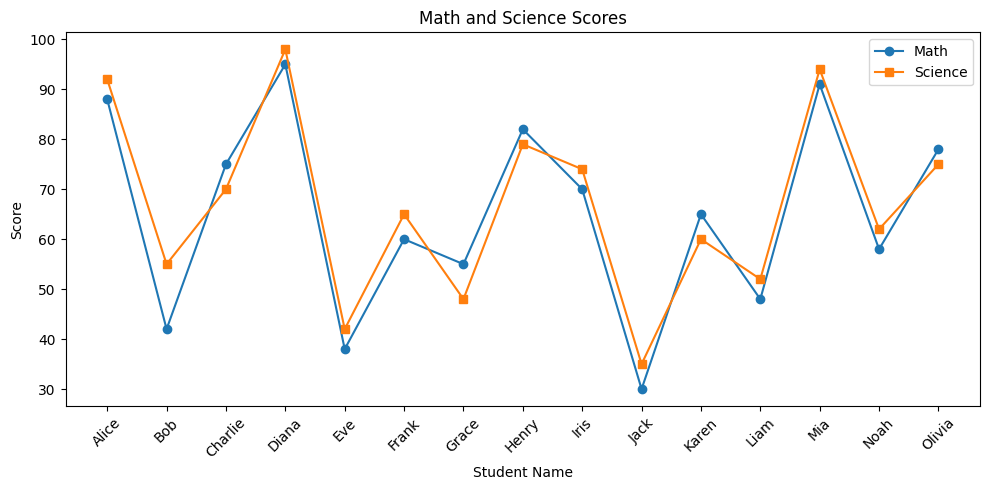

In [15]:
plt.figure(figsize=(10,5))

plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="s", label="Science")

plt.xticks(rotation=45)
plt.title("Math and Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

In [16]:
# ---------------------------------------------
# Task 3 -  Data Visualization with Seaborn
# ---------------------------------------------



Plot 6 — Seaborn bar plot

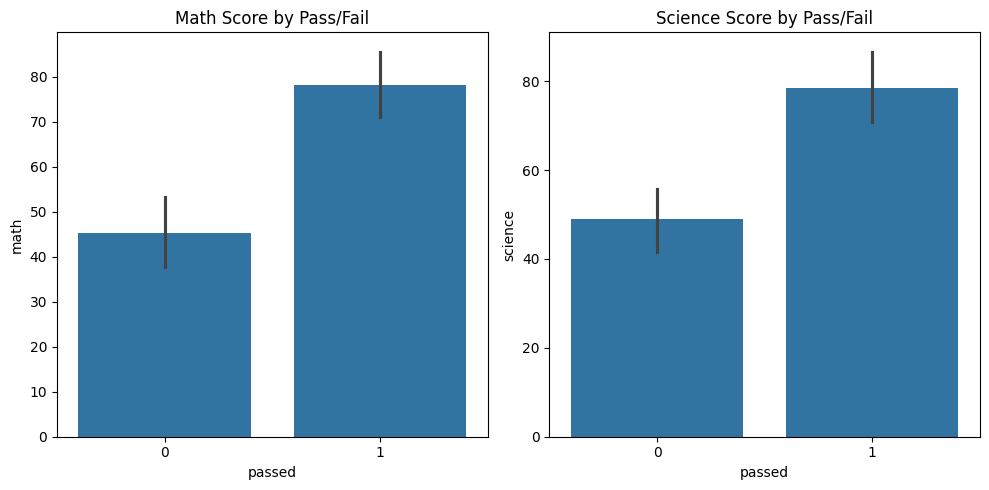

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(data=df, x="passed", y="math", ax=ax1)
ax1.set_title("Math Score by Pass/Fail")

sns.barplot(data=df, x="passed", y="science", ax=ax2)
ax2.set_title("Science Score by Pass/Fail")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

Plot 7 — Seaborn scatter and regression

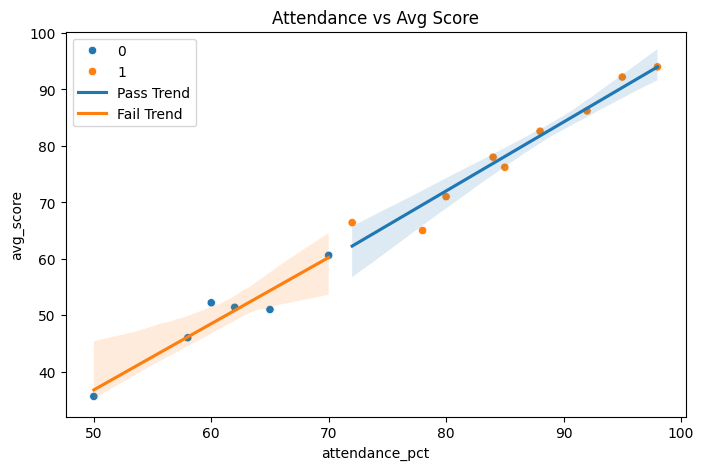

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attendance_pct",
    y="avg_score",
    hue="passed"
)

sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Pass Trend"
)

sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Fail Trend"
)

plt.legend()
plt.title("Attendance vs Avg Score")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [19]:
# Seaborn made bar plots and regression lines easier to create with less code compared to Matplotlib.
# Matplotlib gave more manual control over labels and styling,but required more code for similar plots.

Training Accuracy: 1.0
Test Accuracy: 1.0
Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅
               feature  coefficient  abs_coef
2              english     0.812513  0.812513
5       attendance_pct     0.521876  0.521876
6  study_hours_per_day     0.484433  0.484433
4                   pe     0.474974  0.474974
0                 math     0.437944  0.437944
1              science     0.323010  0.323010
3              history     0.262929  0.262929


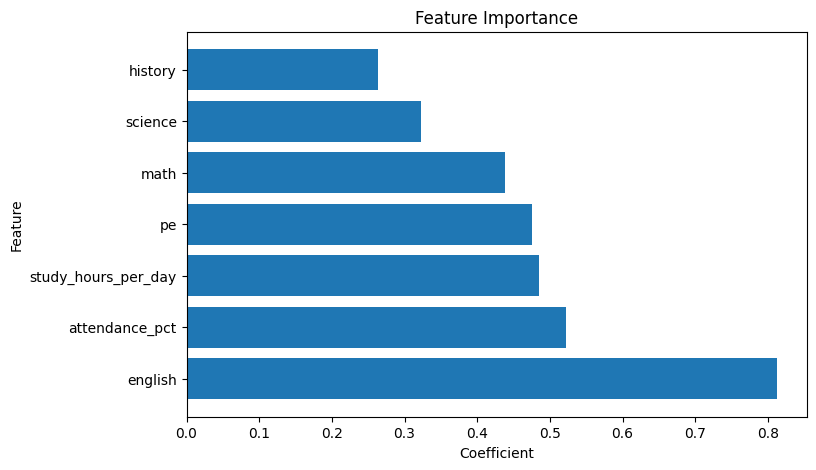

In [20]:
# ---------------------------------------------
# Task 4 -  Machine Learning with scikit-learn
# ---------------------------------------------

# STEP1 - Prepare the data

feature_cols = [
    "math", "science", "english",
    "history", "pe",
    "attendance_pct",
    "study_hours_per_day"
]

X = df[feature_cols]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

# Step 2 - Training the model

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)


# Step 3 - Evaluate the Model:

y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_acc)

test_names = df.loc[X_test.index, "name"]

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅" if actual == pred else "❌"
    print(name, actual, pred, status)

# Step 4 - Feature Importance

coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients
})

importance_df["abs_coef"] = importance_df["coefficient"].abs()

importance_df = importance_df.sort_values(
    by="abs_coef",
    ascending=False
)

print(importance_df)

colors = [
    "green" if x > 0 else "red"
    for x in importance_df["coefficient"]
]

plt.figure(figsize=(8,5))
plt.barh(
    importance_df["feature"],
    importance_df["coefficient"]
)

plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()


In [21]:
# Step 5 — Predict for a New Student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

print("Probability:", probability)


Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
